In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torch import nn
import torch.optim as optim
import torch.nn as nn
from srcnn_model import SRCNN
from dataloader import PassiveMicrowaveDataset, split_data
import torch
from torch.utils.data import Dataset, DataLoader
import xarray as xr
import numpy as np
import os
import cv2
from torchvision.transforms import ToTensor
import os

# Load dataset and split it
all_paths = []
for year in range(2003, 2021):
    for month in range(1, 13):
        folder_path = f"/lustre/storeB/project/metkl/DigitalSeaIce/are-phd/SuperResolutionSeaIce/Dataset/AMSRSSMI/{year}/{month:02d}"
        if os.path.exists(folder_path):
            for file_name in os.listdir(folder_path):
                if file_name.endswith(".nc"):
                    all_paths.append(os.path.join(folder_path, file_name))
        else:
            print(f"Warning: Directory {folder_path} does not exist. Skipping...")

train_paths, val_paths, test_paths = split_data(all_paths)

train_dataset = PassiveMicrowaveDataset(train_paths[:20], transform=ToTensor(), use_bicubic=True)
val_dataset = PassiveMicrowaveDataset(val_paths[:10], transform=ToTensor(), use_bicubic=True)
test_dataset = PassiveMicrowaveDataset(test_paths[:10], transform=ToTensor(), use_bicubic=True)


train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

# Initialize and load SRCNN model
model = SRCNN()
model.load_state_dict(torch.load("srcnn_model.pth", map_location=torch.device("cpu")))
model.eval()  # Set the model to evaluation mode

# Move model to device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Get one batch from the test loader
data_iter = iter(test_loader)
low_res_batch, high_res_batch = next(data_iter)

# Select the first image from the batch
low_res_image = low_res_batch[0].unsqueeze(0).to(device)  # Shape: (1, C, H, W)
high_res_true = high_res_batch[0].cpu().numpy()  # Ground truth HR for comparison

# Apply SRCNN model
with torch.no_grad():
    high_res_pred = model(low_res_image)

# Convert tensors back to numpy
low_res_np = low_res_image.squeeze(0).cpu().numpy()  # Remove batch dimension
print(low_res_np.shape)
high_res_pred_np = high_res_pred.squeeze(0).cpu().numpy()


(2, 416, 416)


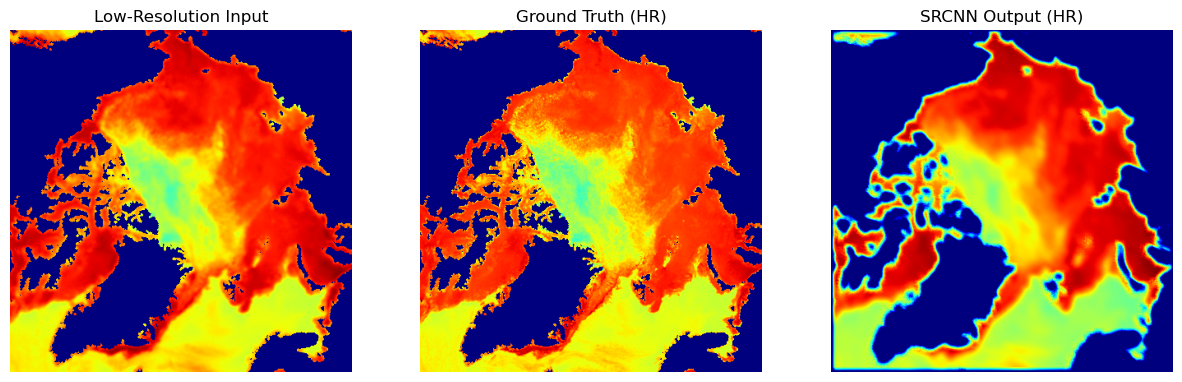

In [14]:

# Visualize Low-Res, Ground Truth, and SRCNN Output
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(low_res_np[0], cmap='jet', vmin=120)
plt.axis('off') 
plt.title("Low-Resolution Input")

plt.subplot(1, 3, 2)
plt.imshow(high_res_true[0], cmap='jet', vmin=120)  # Ground Truth
plt.axis('off') 
plt.title("Ground Truth (HR)")

plt.subplot(1, 3, 3)
plt.imshow(high_res_pred_np[0], cmap='jet', vmin=120)  # SRCNN Output
plt.axis('off') 
plt.title("SRCNN Output (HR)")

plt.savefig('figures/qualitative_testing.png')
plt.show()

